In [2]:
pip install pandas numpy matplotlib seaborn plotly

In [63]:
#Import Required Libraries

import pandas as pd
import numpy as np

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [4]:
# Load Dataset

df = pd.read_csv("covid_19_clean_complete.csv")

In [5]:
# Dataset overview
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [7]:
df.shape

(49068, 10)

In [8]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.dtypes

,0
Province/State,object
Country/Region,object
Lat,float64
Long,float64
Date,datetime64[ns]
Confirmed,int64
Deaths,int64
Recovered,int64
Active,int64
WHO Region,object


In [11]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.rename(columns={
    'Country/Region': 'Country'
})

In [14]:
df['Death_Rate'] = (df['Deaths'] / df['Confirmed']) * 100

In [15]:
pd.options.display.float_format = '{:.0f}'.format

In [16]:
df[['Confirmed', 'Deaths', 'Recovered', 'Active']].describe()

,Confirmed,Deaths,Recovered,Active
count,49068,49068,49068,49068
mean,16885,884,7916,8085
std,127300,6314,54801,76259
min,0,0,0,-14
25%,4,0,0,0
50%,168,2,29,26
75%,1518,30,666,606
max,4290259,148011,1846641,2816444


In [17]:
country_summary = df.groupby('Country')[['Confirmed', 'Deaths']].max().reset_index()

In [18]:
country_summary.sort_values(by='Confirmed', ascending=False).head(10)

,Country,Confirmed,Deaths
173,US,4290259,148011
23,Brazil,2442375,87618
79,India,1480073,33408
138,Russia,816680,13334
154,South Africa,452529,7067
111,Mexico,395489,44022
132,Peru,389717,18418
35,Chile,347923,9187
177,United Kingdom,300111,45759
81,Iran,293606,15912


In [19]:
global_trend = df.groupby('Date')['Confirmed'].sum().reset_index()

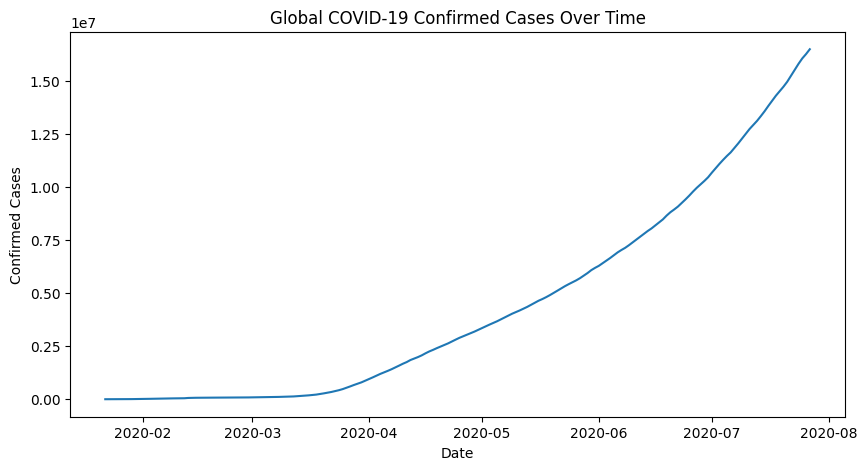

In [20]:
plt.figure(figsize=(10,5))
plt.plot(global_trend['Date'], global_trend['Confirmed'])
plt.title("Global COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

In [21]:
top10 = country_summary.sort_values(by='Confirmed', ascending=False).head(10)

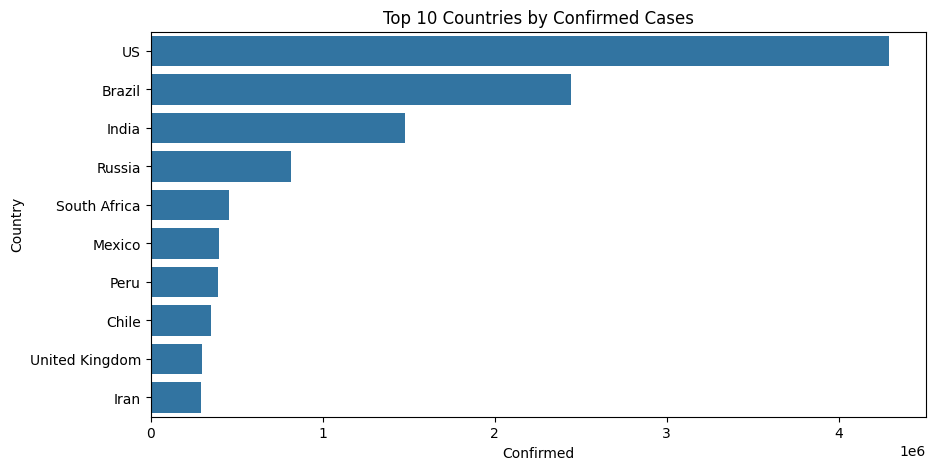

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=top10, x='Confirmed', y='Country')
plt.title("Top 10 Countries by Confirmed Cases")
plt.show()

In [23]:
df['Month'] = df['Date'].dt.to_period('M')

In [24]:
monthly_cases = df.groupby('Month')['Confirmed'].sum().reset_index()
monthly_cases['Month'] = monthly_cases['Month'].astype(str)


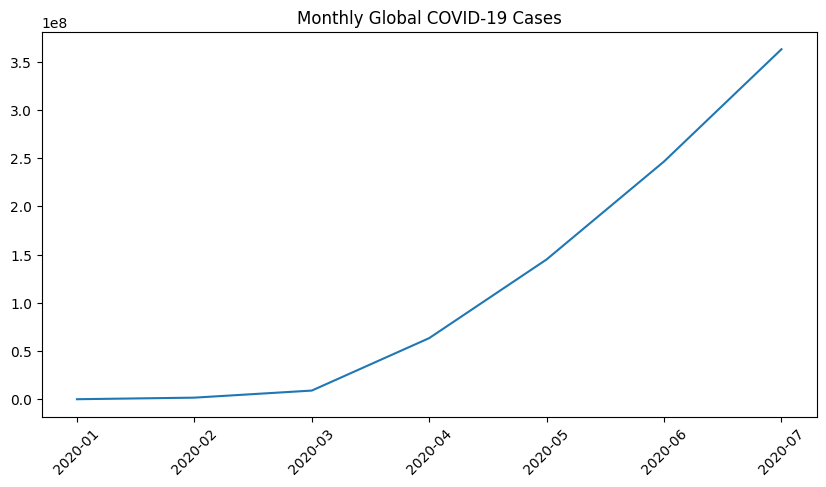

In [25]:
plt.figure(figsize=(10,5))
plt.plot(monthly_cases['Month'], monthly_cases['Confirmed'])
plt.xticks(rotation=45)
plt.title("Monthly Global COVID-19 Cases")
plt.show()


In [26]:
fig = px.line(
    global_trend,
    x='Date',
    y='Confirmed',
    title='Global COVID-19 Trend (Interactive)'
)

fig.show()

In [27]:
ts = df.groupby('Date')['Confirmed'].sum()

In [28]:
ts.head()

,Confirmed
Date,
2020-01-22,555
2020-01-23,654
2020-01-24,941
2020-01-25,1434
2020-01-26,2118


In [29]:
pip install statsmodels

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [31]:
decomposition = seasonal_decompose(ts, model='additive', period=7)

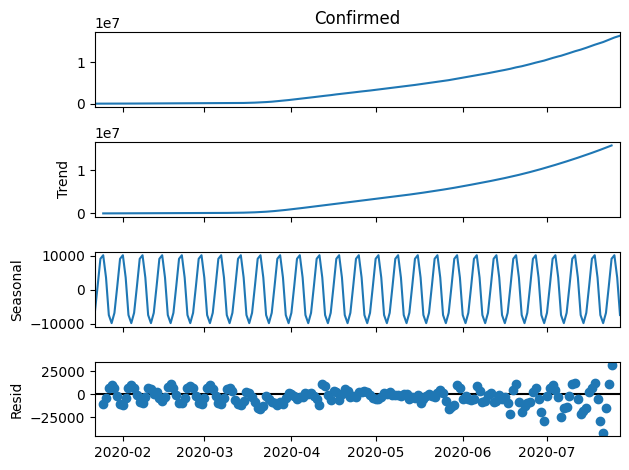

In [32]:
decomposition.plot()
plt.show()

In [33]:
trend = decomposition.trend

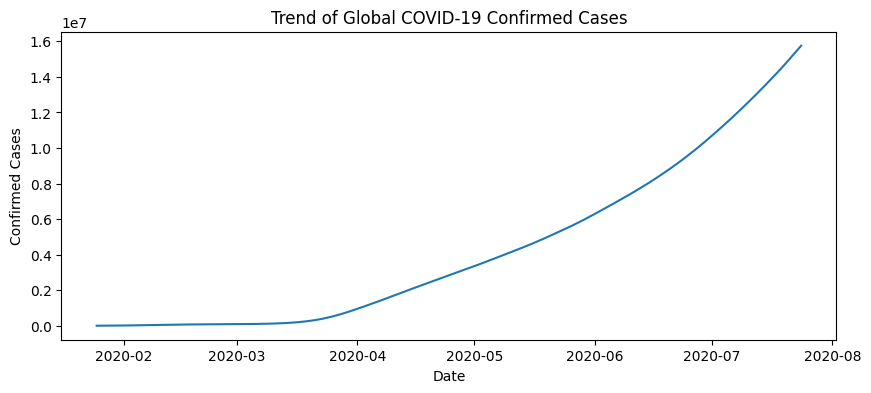

In [34]:
plt.figure(figsize=(10,4))
plt.plot(trend)
plt.title("Trend of Global COVID-19 Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

In [35]:
seasonal = decomposition.seasonal

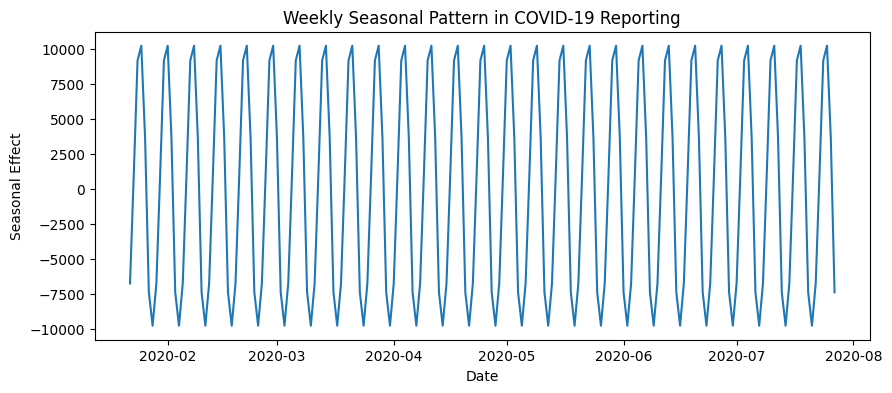

In [36]:
plt.figure(figsize=(10,4))
plt.plot(seasonal)
plt.title("Weekly Seasonal Pattern in COVID-19 Reporting")
plt.xlabel("Date")
plt.ylabel("Seasonal Effect")
plt.show()

In [37]:
residual = decomposition.resid

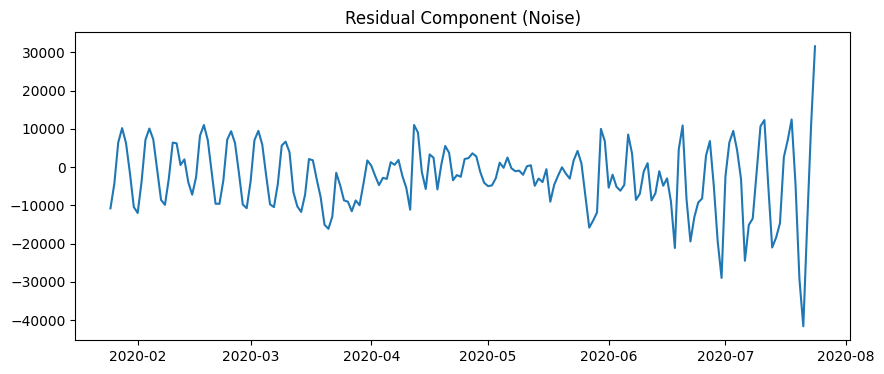

In [38]:
plt.figure(figsize=(10,4))
plt.plot(residual)
plt.title("Residual Component (Noise)")
plt.show()

In [39]:
from statsmodels.tsa.arima.model import ARIMA


In [40]:
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.



In [41]:
forecast = model_fit.forecast(steps=30)

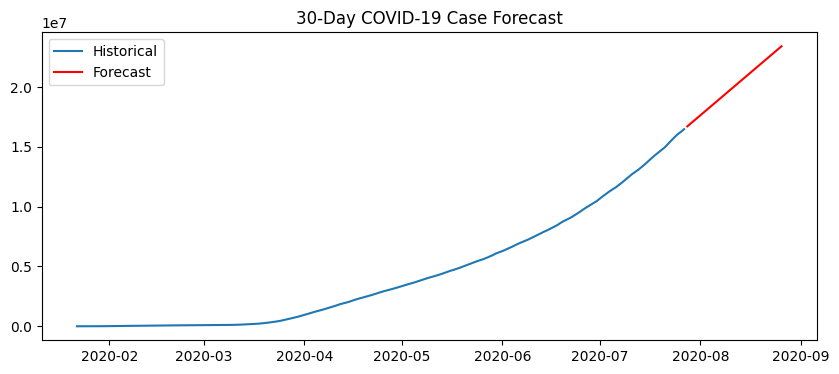

In [42]:
plt.figure(figsize=(10,4))
plt.plot(ts, label='Historical')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("30-Day COVID-19 Case Forecast")
plt.show()

In [43]:
latest_date = df['Date'].max()
latest_date

Timestamp('2020-07-27 00:00:00')

In [44]:
latest_df = df[df['Date'] == latest_date]
latest_df.head()

,Province/State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Death_Rate,Month
48807,NaN,Afghanistan,34,68,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean,3,2020-07
48808,NaN,Albania,41,20,2020-07-27,4880,144,2745,1991,Europe,3,2020-07
48809,NaN,Algeria,28,2,2020-07-27,27973,1163,18837,7973,Africa,4,2020-07
48810,NaN,Andorra,43,2,2020-07-27,907,52,803,52,Europe,6,2020-07
48811,NaN,Angola,-11,18,2020-07-27,950,41,242,667,Africa,4,2020-07


In [45]:
geo_df = (
    latest_df
    .groupby('Country')[['Confirmed', 'Deaths', 'Recovered', 'Active']]
    .sum()
    .reset_index()
)

In [46]:
geo_df.head()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667


In [47]:
pip install folium

In [48]:
import folium

In [49]:
world_map = folium.Map(location=[20, 0], zoom_start=2)
world_map

In [50]:
folium.Choropleth(
    geo_data="https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json",
    data=geo_df,
    columns=["Country", "Confirmed"],
    key_on="feature.properties.name",
    fill_color="Reds",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Confirmed COVID-19 Cases (Latest Date)"
).add_to(world_map)

world_map

In [51]:
death_map = folium.Map(location=[20, 0], zoom_start=2)

folium.Choropleth(
    geo_data="https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json",
    data=geo_df,
    columns=["Country", "Deaths"],
    key_on="feature.properties.name",
    fill_color="Blues",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="COVID-19 Deaths (Latest Date)"
).add_to(death_map)

death_map

In [52]:
top5 = (
    df.groupby('Country')['Confirmed'].max()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top5_df = df[df['Country'].isin(top5)]

stack_df = (
    top5_df
    .groupby(['Date','Country'])['Confirmed']
    .sum()
    .reset_index()
)

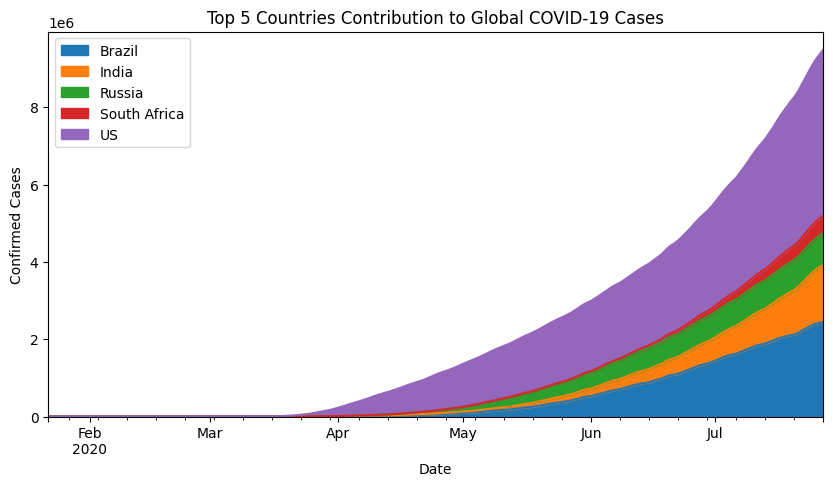

In [53]:
import matplotlib.pyplot as plt

pivot_df = stack_df.pivot(index='Date', columns='Country', values='Confirmed').fillna(0)

pivot_df.plot.area(figsize=(10,5))
plt.title("Top 5 Countries Contribution to Global COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend(loc='upper left')
plt.show()

In [54]:
latest_date = df['Date'].max()
bubble_df = df[df['Date'] == latest_date]

bubble_df = (
    bubble_df.groupby('Country')[['Confirmed','Deaths','Active']]
    .sum()
    .reset_index()
)

In [55]:
import plotly.express as px

fig = px.scatter(
    bubble_df,
    x='Confirmed',
    y='Deaths',
    size='Active',
    hover_name='Country',
    title='COVID-19 Impact by Country (Bubble Chart)'
)
fig.show()

In [61]:
geo_df.to_csv("covid_tableau_final.csv", index=False)

In [79]:
# =========================
# COVID DASHBOARD
# =========================


df_dash = df.copy()

# Standardize common alternate column names
rename_map = {
    "Country/Region": "Country",
    "ObservationDate": "Date",
    "Last Update": "Date",
    "Last_Update": "Date",
    "ConfirmedCases": "Confirmed",
    "DeathsCases": "Deaths",
}
df_dash = df_dash.rename(columns={k: v for k, v in rename_map.items() if k in df_dash.columns})

required = ["Country", "Date", "Confirmed", "Deaths"]
missing = [c for c in required if c not in df_dash.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}. Your columns are: {list(df_dash.columns)}")

# Ensure Date is datetime
df_dash["Date"] = pd.to_datetime(df_dash["Date"], errors="coerce")
df_dash = df_dash.dropna(subset=["Date"])

# Ensure numeric
for col in ["Confirmed", "Deaths"]:
    df_dash[col] = pd.to_numeric(df_dash[col], errors="coerce").fillna(0)

# Add optional cols safely
if "Recovered" not in df_dash.columns:
    df_dash["Recovered"] = 0
else:
    df_dash["Recovered"] = pd.to_numeric(df_dash["Recovered"], errors="coerce").fillna(0)

if "Active" not in df_dash.columns:
    df_dash["Active"] = (df_dash["Confirmed"] - df_dash["Deaths"] - df_dash["Recovered"]).clip(lower=0)
else:
    df_dash["Active"] = pd.to_numeric(df_dash["Active"], errors="coerce").fillna(0)

# ---------- 2) Build aggregates ----------
latest_date = df_dash["Date"].max()

latest_geo = (
    df_dash[df_dash["Date"] == latest_date]
    .groupby("Country")[["Confirmed", "Deaths", "Recovered", "Active"]]
    .sum()
    .reset_index()
)

# KPIs
kpi_confirmed = 828508482
kpi_deaths    = 43384903
kpi_recovered = 388408229
kpi_active    = 396715350

# Global time series
global_trend = (
    df_dash.groupby("Date")[["Confirmed", "Deaths", "Recovered", "Active"]]
    .sum()
    .reset_index()
    .sort_values("Date")
)

# Country max summary (max over time)
country_summary = (
    df_dash.groupby("Country")[["Confirmed", "Deaths"]]
    .max()
    .reset_index()
)

top10 = (
    country_summary.sort_values("Confirmed", ascending=False)
    .head(10)
    .sort_values("Confirmed", ascending=True)
)

# Bubble data + Death_Rate
bubble = latest_geo.copy()
bubble["Death_Rate"] = np.where(
    bubble["Confirmed"].to_numpy() > 0,
    (bubble["Deaths"].to_numpy() / bubble["Confirmed"].to_numpy()) * 100.0,
    0.0
)

# Bubble marker sizing
max_deaths = max(float(bubble["Deaths"].max()), 1.0)
bubble_size = (bubble["Deaths"] / max_deaths * 35 + 6).clip(lower=6)

# ---------- 3) Create dashboard layout ----------
fig = make_subplots(
    rows=3, cols=4,
    row_heights=[0.25, 0.45, 0.30],
    column_widths=[0.25, 0.25, 0.25, 0.25],
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy", "colspan": 2}, None, {"type": "xy", "colspan": 2}, None],
        [{"type": "choropleth", "colspan": 2}, None, {"type": "xy", "colspan": 2}, None],
    ],
    subplot_titles=(
        "Confirmed (Latest)", "Deaths (Latest)", "Recovered (Latest)", "Active (Latest)",
        "Global Trend (Confirmed)", "Top 10 Countries (Confirmed - Max)",
        "World Map (Confirmed - Latest)", "Bubble: Active vs Confirmed (Latest)"
    )
)

# KPI cards
fig.add_trace(go.Indicator(mode="number", value=kpi_confirmed, number={"valueformat": ","}), row=1, col=1)
fig.add_trace(go.Indicator(mode="number", value=kpi_deaths,    number={"valueformat": ","}), row=1, col=2)
fig.add_trace(go.Indicator(mode="number", value=kpi_recovered, number={"valueformat": ","}), row=1, col=3)
fig.add_trace(go.Indicator(mode="number", value=kpi_active,    number={"valueformat": ","}), row=1, col=4)

# Global trend line
fig.add_trace(
    go.Scatter(
        x=global_trend["Date"],
        y=global_trend["Confirmed"],
        mode="lines",
        name="Global Confirmed"
    ),
    row=2, col=1
)

# Top10 bar
fig.add_trace(
    go.Bar(
        x=top10["Confirmed"],
        y=top10["Country"],
        orientation="h",
        name="Top 10"
    ),
    row=2, col=3
)

# Choropleth map
fig.add_trace(
    go.Choropleth(
        locations=latest_geo["Country"],
        locationmode="country names",
        z=latest_geo["Confirmed"],
        colorbar_title="Confirmed",
        name="Confirmed Map"
    ),
    row=3, col=1
)

# Bubble scatter
fig.add_trace(
    go.Scatter(
        x=bubble["Confirmed"],
        y=bubble["Active"],
        mode="markers",
        text=bubble["Country"],
        customdata=bubble["Death_Rate"],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Confirmed: %{x:,}<br>"
            "Active: %{y:,}<br>"
            "Death Rate: %{customdata:.2f}%<extra></extra>"
        ),
        marker=dict(size=bubble_size)
    ),
    row=3, col=3
)

# Layout polish
fig.update_layout(
    title=f"GLOBAL IMPACT OF COVID 19: DATA VISUALIZATION",
    height=950,
    showlegend=False,
    margin=dict(l=30, r=30, t=70, b=30)
)

# Axis labels
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Confirmed", row=2, col=1)

fig.update_xaxes(title_text="Confirmed (Max)", row=2, col=3)
fig.update_yaxes(title_text="Country", row=2, col=3)

fig.update_xaxes(title_text="Confirmed (Latest)", row=3, col=3)
fig.update_yaxes(title_text="Active (Latest)", row=3, col=3)

# DISPLAY
fig.show()
